In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import json
from pathlib import Path
import random
from PIL import Image
import os
import sys
import io
import numpy as np
import torch
from omegaconf import OmegaConf
from torchvision import transforms

src_path = '/mnt/DATA2/dorin/Image-Transform-Predict/src'
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from seq_iou_bench import LengthWiseAccuracyBenchmark
from dataset import ImageTransformer
from dataset import TransformTokenizer
from model import ImageTransformPredictor

%load_ext autoreload
%autoreload 2

In [2]:
# !pip install efficientnet_pytorch
# !pip install --upgrade torchvision

## DomainNet

In [3]:
from seq_iou_bench import DomainNetFullBenchmark

In [2]:
preprocess_effnet = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_011.yaml')
model_effnet = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model_effnet.load_state_dict(checkpoint['model_state_dict'])
model_effnet.to('cuda')
model_effnet.eval()
print('ready')

Loaded pretrained weights for efficientnet-b3
ready


In [4]:
preprocess_vit = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_vit.yaml')
model_vit = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model_vit.load_state_dict(checkpoint['model_state_dict'])
model_vit.to('cuda')
model_vit.eval()
print('ready')

ready


In [1]:
import torch

from transformers import AutoTokenizer, AutoProcessor
from transformers import Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
from PIL import Image

if not hasattr(torch.compiler, "is_compiling"):
    torch.compiler.is_compiling = lambda: False

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
)

# Store processor for preprocessing
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

model.to("cuda")
print('ready')

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ready


In [2]:
total = model.num_parameters()                       # = sum(p.numel() ...), tied-веса считаются один раз
print(f"{total:,}  ({total/1e9:.3f} B)")

4,437,815,808  (4.438 B)


In [5]:
tokenizer = TransformTokenizer()
transformer = ImageTransformer()

In [6]:
data_path = "/mnt/DATA2/dorin/Image-Transform-Predict/data"

In [7]:
device = torch.device("cuda")

benchmark = DomainNetFullBenchmark(
    model=model_effnet,
    dataset_root=data_path,
    transformer=transformer,
    tokenizer=tokenizer,
    preprocess=preprocess_effnet,
    device=device,
    model_type="custom"
)

results = benchmark.run(model_name="Ours-EffNet-pre", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_domainnet.json")

DomainNet val: 100%|██████████| 58654/58654 [42:50<00:00, 22.82it/s] 



DomainNet full validation benchmark completed for 'Ours-EffNet-pre'
   Transform probability (p): 0.3
   Overall Jaccard = 0.9499 (N=58654)

Per-domain results:
   clipart: Jaccard = 0.9137 (N=4812)
   infograph: Jaccard = 0.9394 (N=5160)
   painting: Jaccard = 0.9522 (N=7226)
   quickdraw: Jaccard = 0.9762 (N=17250)
   real: Jaccard = 0.9464 (N=17294)
   sketch: Jaccard = 0.9314 (N=6912)

Saved to: /mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_domainnet.json


In [8]:
device = torch.device("cuda")

benchmark = DomainNetFullBenchmark(
    model=model_vit,
    dataset_root=data_path,
    transformer=transformer,
    tokenizer=tokenizer,
    preprocess=preprocess_vit,
    device=device,
    model_type="custom"
)

results = benchmark.run(model_name="Ours-ViT-pre", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_domainnet.json")

DomainNet val: 100%|██████████| 58654/58654 [27:01<00:00, 36.18it/s] 



DomainNet full validation benchmark completed for 'Ours-ViT-pre'
   Transform probability (p): 0.3
   Overall Jaccard = 0.8559 (N=58654)

Per-domain results:
   clipart: Jaccard = 0.8279 (N=4812)
   infograph: Jaccard = 0.8230 (N=5160)
   painting: Jaccard = 0.8517 (N=7226)
   quickdraw: Jaccard = 0.8686 (N=17250)
   real: Jaccard = 0.8725 (N=17294)
   sketch: Jaccard = 0.8349 (N=6912)

Saved to: /mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_domainnet.json


In [10]:
# device = torch.device("cuda")

# benchmark = DomainNetFullBenchmark(
#     model=model,
#     dataset_root=data_path,
#     transformer=transformer,
#     tokenizer=None,
#     preprocess=processor,
#     device=device,
#     model_type="qwen"
# )

# results = benchmark.run(model_name="Qwen3-VL-4B", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_domainnet.json")

## Negative Dataset

### Evaluation of sequence prediction models (ViT based, EfficientNet based)

In [6]:
data_json_path = "/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/filtered_negative_test_dataset_meta.json"

tokenizer = TransformTokenizer()
transformer = ImageTransformer()

In [14]:
preprocess_effnet = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_011.yaml')
model_effnet = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/checkpoint_epoch_50.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model_effnet.load_state_dict(checkpoint['model_state_dict'])
model_effnet.to('cuda')
model_effnet.eval()
print('ready')

Loaded pretrained weights for efficientnet-b3
ready


In [11]:
preprocess_vit = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_vit.yaml')
model_vit = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model_vit.load_state_dict(checkpoint['model_state_dict'])
model_vit.to('cuda')
model_vit.eval()
print('ready')

ready


In [7]:
device = torch.device("cuda")

benchmark = LengthWiseAccuracyBenchmark(
    model=model_vit,
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path=data_json_path,
    preprocess=preprocess_vit,
    transformer=transformer,
    tokenizer=tokenizer,
    config=config,
    device=device,
    n_samples_per_length=1000,
    seed=2026
)

results = benchmark.run(model_name="Ours-ViT-sft", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json")

  k=1: Jaccard=0.9217, TokAcc=0.9735 (N=1000)


  k=2: Jaccard=0.9761, TokAcc=0.8123 (N=1000)


  k=3: Jaccard=0.9558, TokAcc=0.6977 (N=1000)


  k=4: Jaccard=0.9527, TokAcc=0.6344 (N=1000)


  k=5: Jaccard=0.9344, TokAcc=0.5750 (N=1000)

Saved length-wise accuracy for 'Ours-ViT-sft' to '/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json'


In [12]:
device = torch.device("cuda")

benchmark = LengthWiseAccuracyBenchmark(
    model=model_effnet,
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path=data_json_path,
    preprocess=preprocess_effnet,
    transformer=transformer,
    tokenizer=tokenizer,
    config=config,
    device=device,
    n_samples_per_length=1000,
    seed=2026
)

results = benchmark.run(model_name="Ours-EffNet-sft", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json")

  k=1: Jaccard=0.9773, TokAcc=0.9920 (N=1000)


  k=2: Jaccard=0.9689, TokAcc=0.8130 (N=1000)


  k=3: Jaccard=0.9547, TokAcc=0.7025 (N=1000)


  k=4: Jaccard=0.9301, TokAcc=0.6288 (N=1000)


  k=5: Jaccard=0.9151, TokAcc=0.5710 (N=1000)

Saved length-wise accuracy for 'Ours-EffNet-sft' to '/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json'


In [13]:
device = torch.device("cuda")

benchmark = LengthWiseAccuracyBenchmark(
    model=model_vit,
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path=data_json_path,
    preprocess=preprocess_vit,
    transformer=transformer,
    tokenizer=tokenizer,
    config=config,
    device=device,
    n_samples_per_length=1000,
    seed=2026
)

results = benchmark.run(model_name="Ours-ViT-pre", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json")

  k=1: Jaccard=0.7964, TokAcc=0.9320 (N=1000)


  k=2: Jaccard=0.8861, TokAcc=0.7733 (N=1000)


  k=3: Jaccard=0.8306, TokAcc=0.6603 (N=1000)


  k=4: Jaccard=0.7913, TokAcc=0.5826 (N=1000)


  k=5: Jaccard=0.7441, TokAcc=0.5173 (N=1000)

Saved length-wise accuracy for 'Ours-ViT-pre' to '/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json'


In [15]:
device = torch.device("cuda")

benchmark = LengthWiseAccuracyBenchmark(
    model=model_effnet,
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path=data_json_path,
    preprocess=preprocess_effnet,
    transformer=transformer,
    tokenizer=tokenizer,
    config=config,
    device=device,
    n_samples_per_length=1000,
    seed=2026
)

results = benchmark.run(model_name="Ours-EffNet-pre", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json")

  k=1: Jaccard=0.9620, TokAcc=0.9855 (N=1000)


  k=2: Jaccard=0.9534, TokAcc=0.8050 (N=1000)


  k=3: Jaccard=0.9313, TokAcc=0.6983 (N=1000)


  k=4: Jaccard=0.9067, TokAcc=0.6220 (N=1000)


  k=5: Jaccard=0.8882, TokAcc=0.5712 (N=1000)

Saved length-wise accuracy for 'Ours-EffNet-pre' to '/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json'


### Comparison with Qwen3-VL-4B-Instruct in the task of predicting the transformation sequence

In [4]:
import torch

from transformers import AutoTokenizer, AutoProcessor
from transformers import Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
from PIL import Image

if not hasattr(torch.compiler, "is_compiling"):
    torch.compiler.is_compiling = lambda: False

from seq_iou_bench import QwenLengthWiseBenchmark

In [4]:
# !pip install transformers==4.57.0
# !pip install qwen_vl_utils

In [3]:
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
)

# Store processor for preprocessing
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

#### An example of how we use VLM to predict a sequence

In [4]:
prompt_seq_prediction = """You are given two images: Image A (original) and Image B (transformed).  
Your task is to predict the sequence of transformations applied to Image A to obtain Image B, using only the following allowed operations:  
"noop", "grayscale", "rotate_90", "rotate_180", "rotate_270", "color_jitter", "noise_adding", "jpeg_artefacts", "crop", "horizontal_flip", "vertical_flip".

- The sequence may contain zero, one, or multiple transformations applied in order.  
- If Image A and Image B are identical, return: ["noop"]
- If Image B can be obtained by applying a sequence of the allowed transformations (in the correct order), return that sequence as a JSON list, e.g.: ["color_jitter", "noise_adding", "rotate_270", "horizontal_flip"]  
- If the transformation from Image A to Image B requires any operation not in the allowed list (e.g., blur, resize, perspective distortion, custom warping, etc.), or if the images are unrelated, return an empty list: []  

Output only the JSON list. Do not add explanations, comments, or extra text."""

In [13]:
prompt_class_prediction = """You are an expert in image forensics. Determine whether Image B is a plagiarized version of Image A, meaning it was obtained by applying only the following allowed transformations to Image A:  
- Geometric: rotate_90, rotate_180, rotate_270, horizontal_flip, vertical_flip  
- Photometric: grayscale, color_jitter  
- Structural: crop (central square)  
- Noise/compression: noise_adding, jpeg_artefacts  

If Image B can be produced from Image A using any combination of these operations (in any order, without repetition), output 1.  
If Image B involves any other transformation (e.g., blur, resize, perspective warp, object removal, or unrelated content), output 0.

Output only a single digit: 1 or 0. Do not add any other text, explanation, or punctuation."""

In [3]:
image = Image.open('../assets/dog.jpg')
image_car = Image.open('/mnt/DATA2/dorin/imgs/car/image1.jpg')
transformed_image, sequence = transformer.transform_by_length(image, 2)

sequence

['vertical_flip', 'grayscale']

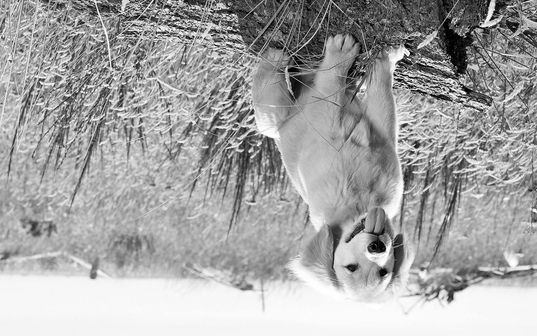

In [4]:
transformed_image

In [41]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "image", "image": transformed_image},
            {"type": "text", "text": prompt_class_prediction},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cpu")

# Inference
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text[0])

0


#### Run benchmark

In [15]:
from seq_iou_bench import QwenLengthWiseBenchmark

benchmark = QwenLengthWiseBenchmark(
    model=model,
    processor=processor,
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path=data_json_path,
    transformer=transformer,
    n_samples_per_length=1000,
    seed=2026
)

benchmark.run(model_name="Qwen3-VL-4B-Instruct", output_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json")

  k=1: Jaccard=0.1504 (N=1000)


  k=2: Jaccard=0.1336 (N=1000)


  k=3: Jaccard=0.1629 (N=1000)


  k=4: Jaccard=0.1791 (N=1000)


  k=5: Jaccard=0.1882 (N=1000)

Saved Qwen length-wise accuracy for 'Qwen3-VL-4B' to '/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/metrics/metrics_v2/seq_iou_negative_dataset.json'


{1: {'jaccard': 0.15044742729306487, 'count': 1000},
 2: {'jaccard': 0.13359840954274355, 'count': 1000},
 3: {'jaccard': 0.16291951775822744, 'count': 1000},
 4: {'jaccard': 0.179125138427464, 'count': 1000},
 5: {'jaccard': 0.18824386689336897, 'count': 1000}}